## Graph with DeepSeek

### Set up DeepSeek

In [1]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("DEEPSEEK_API_KEY")

In [2]:
from langchain_deepseek import ChatDeepSeek

dp = ChatDeepSeek(
    model="deepseek-v4-flash",
    temperature=0,
    max_tokens=None,
    max_retries=2,
)

## Set up the graph

In [3]:
from langgraph.graph import MessagesState
from langchain_core.messages import HumanMessage, SystemMessage

sys_msg = SystemMessage(content="You are a helpful assistant to respond to general purpose queries.")

# Node is a function that takes in a MessagesState obj
def assistant(state: MessagesState):
    return {"messages": [dp.invoke([sys_msg] + state["messages"])]}

/Users/freedom/Desktop/LangGraphDemo/.venv/lib/python3.12/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


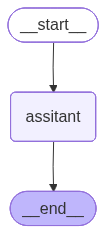

In [4]:
from langgraph.graph import START, StateGraph, END
from IPython.display import Image, display

builder = StateGraph(MessagesState)

# Node
node_name = "assitant"
builder.add_node(node_name, assistant)

# Edges
builder.add_edge(START, node_name)
builder.add_edge(node_name, END)

graph = builder.compile()

display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

## Use the graph

In [5]:
messages = [HumanMessage(content="Tell me the population in Guangzhou.")]
messages = graph.invoke({"messages" : messages})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

Tell me the population in Guangzhou.
================================== Ai Message ==================================

As of the 2020 Chinese census, the population of Guangzhou (the administrative area) was approximately **18.68 million**. More recent estimates (2023) place it around **19 million**, though this can vary depending on the source and whether it includes transient residents.


# Integration with Tools

In [6]:
import datetime

def shop_open_hours() -> str:
    "This tool provides the daily opening hours schedule for a shop."
    schedule = """Monday to Friday: 10:00am to 08:00pm
                Saturday: 9:00am to 08:00pm
                Sunday: 3:00pm to 06:00pm"""
    return schedule

def current_time() -> datetime:
    "This tool provides the current date and time."
    return datetime.datetime.now()

tools = [shop_open_hours, current_time]

In [7]:
from langgraph.graph import MessagesState
from langchain_core.messages import HumanMessage, SystemMessage


content="""You are a helpful assistant responsible
for determining whehter a shop is open or closed, 
based on the current date and time and the shop's opening schedule."""
sys_msg = SystemMessage(content=content)

dp = ChatDeepSeek(
    model="deepseek-chat", # for compitibility with reasoning_content field
    temperature=0,
    max_tokens=None,
    max_retries=2,
)
# Tools
dp_with_tools = dp.bind_tools(tools)

def assistant(state: MessagesState):
    return {"messages": [dp_with_tools.invoke([sys_msg] + state["messages"])]}

## Build graph

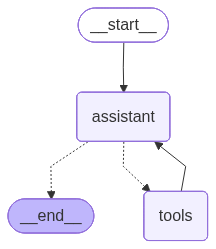

In [8]:
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import tools_condition
from langgraph.prebuilt import ToolNode
from IPython.display import Image, display

builder = StateGraph(MessagesState)

builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "assistant")
builder.add_conditional_edges("assistant", tools_condition)
builder.add_edge("tools", "assistant")

graph = builder.compile()

display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [9]:
messages = [HumanMessage(content="Tell me if the shop is open right now.")]
messages = graph.invoke({"messages" : messages})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

Tell me if the shop is open right now.
================================== Ai Message ==================================

Let me check the current time and the shop's opening hours.
Tool Calls:
  current_time (call_00_VCEKgDdroWYmxRKRoA8B7389)
 Call ID: call_00_VCEKgDdroWYmxRKRoA8B7389
  Args:
  shop_open_hours (call_01_T0hDdkoqNJqHAO5Xk8Rx7602)
 Call ID: call_01_T0hDdkoqNJqHAO5Xk8Rx7602
  Args:
================================= Tool Message =================================
Name: current_time

2026-05-09 20:01:24.480366
================================= Tool Message =================================
Name: shop_open_hours

Monday to Friday: 10:00am to 08:00pm
                Saturday: 9:00am to 08:00pm
                Sunday: 3:00pm to 06:00pm
================================== Ai Message ==================================

Let me analyze this:

**Current time:** Saturday, May 9, 2026 at **8:01 PM** (20:01